 ### Iterative Self-Reflection RAG

- Iterative Self-Reflection RAG is an advanced Retrieval-Augmented Generation (RAG) technique where the LLM evaluates its own answer before returning it to the user.

- Instead of performing a single retrieval and generation step, the system:

    - Retrieves relevant documents.
   - Generates an answer.
    - Reflects on the quality of the answer.
    - Decides whether the answer is sufficient.
    - If not, reformulates the query and retrieves again.
    - Repeats until a satisfactory answer is produced or a retry limit is reached.

    
 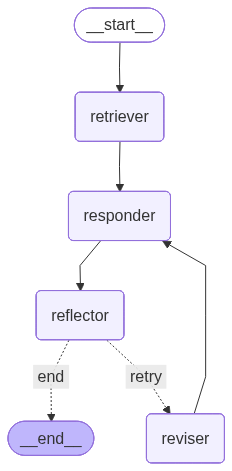

In [1]:
import os
from  typing import List , Annotated, TypedDict, Sequence, Literal
from pydantic import BaseModel, Field

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from  typing import List , Annotated, TypedDict, Sequence, Literal
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate


from langchain_groq import ChatGroq

/tmp/ipykernel_10376/4119248320.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
/workspaces/AgenticAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [8]:
import os
from dotenv import load_dotenv
load_dotenv()




True

In [9]:
# Initialize global ChatGroq model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="qwen/qwen3-32b")


In [10]:
### 1. Document Processing

urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/integrations/providers/overview"
]

loaders = [WebBaseLoader(url) for url in urls]

docs=[]

for loader in loaders:
    docs.extend(loader.load())

docs

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrations

In [11]:
## 2. Recursive character txt splitter as vector store

splitter =RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(split_docs, embedding)
retriever= vectorstore.as_retriever()

retriever.invoke("what is reward function") # test the retriever

[Document(id='22568958-e575-4b00-b6ea-406e143cabfc', metadata={'source': 'https://docs.langchain.com/oss/python/integrations/providers/overview', 'title': 'LangChain Python integrations - Docs by LangChain', 'description': 'Integrate with providers using LangChain Python.', 'language': 'en'}, page_content='A provider is a company or platform that hosts AI models and exposes them through an API (e.g., OpenAI, Anthropic, Google). Many providers have a dedicated langchain-<provider> package that implements one or more of LangChain’s standard interfaces—chat models, embedding models, vector stores, and more—giving you a consistent API regardless of the underlying provider. Install the package, pick a model name, and swap providers without changing your code.'),
 Document(id='ca4c8ddf-bbbd-4420-a25e-964a4aa02e27', metadata={'source': 'https://docs.langchain.com/oss/python/integrations/providers/overview', 'title': 'LangChain Python integrations - Docs by LangChain', 'description': 'Integrat

In [14]:
from typing import Dict, List
from pydantic import BaseModel, Field

class ReflectionRAGState(BaseModel):
    question: str
    retrieved_docs: Dict[str, List[str]] = Field(default_factory=dict)
    answer: str = ""
    reflection: str = ""
    revised: bool = False
    attempts: int = 0

In [15]:
# nodes
def retrieve_docs(state: ReflectionRAGState) -> ReflectionRAGState:
    docs = retriever.invoke(state.question)

    state.retrieved_docs = {
        f"attempt_{state.attempts}": [
            doc.page_content for doc in docs
        ]
    }

    return state

In [16]:
def generate_answer(state: ReflectionRAGState) -> ReflectionRAGState:
    context = ""

    for attempt, docs in state.retrieved_docs.items():
        context += f"\n{attempt}:\n"
        for doc in docs:
            context += f"- {doc}\n"

    prompt = f"""
Answer using only the retrieved context.

Question:
{state.question}

Context:
{context}

Answer:
"""

    response = llm.invoke(prompt).content

    state.answer = response   # important

    return state

In [17]:
def reflect_answer(state: ReflectionRAGState) -> ReflectionRAGState:
    context = ""

    for attempt, docs in state.retrieved_docs.items():
        context += f"\n{attempt}:\n"
        for doc in docs:
            context += f"- {doc[:500]}\n"

    print("========== DEBUG REFLECTOR ==========")
    print("QUESTION:", state.question)
    print("ANSWER EMPTY?", state.answer == "")
    print("DOCS EMPTY?", state.retrieved_docs == {})
    print("ANSWER:", state.answer[:500])
    print("====================================")

    if not state.answer.strip():
        state.reflection = "FAIL"
        return state

    if not state.retrieved_docs:
        state.reflection = "FAIL"
        return state

    prompt = fprompt = f"""
You are evaluating a RAG system.

Question:
{state.question}

Retrieved Context:
{context}

Generated Answer:
{state.answer}

Evaluation Rules:

PASS if:
- The user's question is directly answered.
- The answer contains enough information to satisfy the user.

FAIL if:
- The answer says information is missing.
- The answer says the context does not contain the information.
- The answer says additional resources are required.
- The answer cannot answer the user's question.
- The answer is incomplete.

Return ONLY:

PASS

or

FAIL
"""

    response = llm.invoke(prompt).content.strip().upper()

    print("RAW REFLECTION RESPONSE:", response)

    if "PASS" in response:
        state.reflection = "PASS"
    else:
        state.reflection = "FAIL"

    return state

In [18]:
def reflection_router(state: ReflectionRAGState):
    if state.reflection == "PASS":
        return "end"

    if state.attempts >= 2:
        return "end"

    return "revise"

In [19]:
def revise_query(state: ReflectionRAGState) -> ReflectionRAGState:
    state.attempts += 1
    state.revised = True

    context = ""

    for attempt, docs in state.retrieved_docs.items():
        context += f"\n{attempt}:\n"
        for doc in docs:
            context += f"- {doc[:500]}\n"

    prompt = f"""
You are improving a search query for a RAG retriever.

Original question:
{state.question}

Previous retrieved context:
{context}

Previous answer:
{state.answer}

The previous answer failed reflection.

Rewrite the question into a better retrieval query.
Return ONLY the improved search query.
"""

    revised_query = llm.invoke(prompt).content.strip()

    docs = retriever.invoke(revised_query)

    state.retrieved_docs[f"attempt_{state.attempts}"] = [
        doc.page_content for doc in docs
    ]

    return state

In [20]:
# Build the state graph
builder = StateGraph(ReflectionRAGState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_answer)
builder.add_node("reviser", revise_query)

builder.add_edge(START, "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")

builder.add_conditional_edges(
    "reflector",
    reflection_router,
    {
        "revise": "reviser",
        "end": END
    }
)

builder.add_edge("reviser", "responder")

graph = builder.compile()

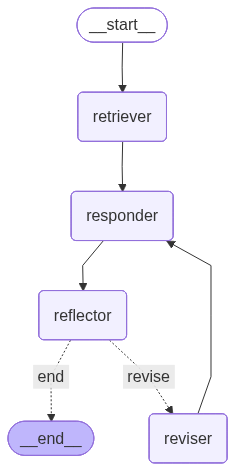

In [21]:
# View the graph
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [22]:
test_question = """
How would you build a production-ready AI agent using LangChain, LangGraph,
and external model providers? Explain the role of each component and how they interact.
"""

result = graph.invoke({
    "question": test_question
})

print("\n========== QUESTION ==========")
print(result["question"])

print("\n========== RETRIEVED DOCS ==========")
for attempt, docs in result["retrieved_docs"].items():
    print(f"\n--- {attempt} ---")
    for i, doc in enumerate(docs, start=1):
        print(f"\nDoc {i}:")
        print(doc[:700])

print("\n========== ANSWER ==========")
print(result["answer"])

print("\n========== REFLECTION ==========")
print(result["reflection"])

print("\n========== REVISED ==========")
print(result["revised"])

print("\n========== ATTEMPTS ==========")
print(result["attempts"])

========== DEBUG REFLECTOR ==========
QUESTION: 
How would you build a production-ready AI agent using LangChain, LangGraph,
and external model providers? Explain the role of each component and how they interact.

ANSWER EMPTY? False
DOCS EMPTY? False
ANSWER: <think>
Okay, so the user is asking how to build a production-ready AI agent using LangChain, LangGraph, and external model providers. They want to know the role of each component and how they interact. Let me break down the context provided to structure the answer correctly.

First, the context mentions that LangChain provides a standard interface for different providers like OpenAI or Anthropic. This makes it easy to switch models without changing code. So, I should explain LangChain's role in
RAW REFLECTION RESPONSE: <THINK>
OKAY, LET'S SEE. THE USER ASKED HOW TO BUILD A PRODUCTION-READY AI AGENT USING LANGCHAIN, LANGGRAPH, AND EXTERNAL MODEL PROVIDERS. THE GENERATED ANSWER EXPLAINS EACH COMPONENT'S ROLE AND THEIR INTERACTION.


In [23]:
# Negative scenario

test_question = """
what is Quantum theory
"""

result = graph.invoke({
    "question": test_question
})

print("\n========== QUESTION ==========")
print(result["question"])

print("\n========== RETRIEVED DOCS ==========")
for attempt, docs in result["retrieved_docs"].items():
    print(f"\n--- {attempt} ---")
    for i, doc in enumerate(docs, start=1):
        print(f"\nDoc {i}:")
        print(doc[:700])

print("\n========== ANSWER ==========")
print(result["answer"])

print("\n========== REFLECTION ==========")
print(result["reflection"])

print("\n========== REVISED ==========")
print(result["revised"])

print("\n========== ATTEMPTS ==========")
print(result["attempts"])

========== DEBUG REFLECTOR ==========
QUESTION: 
what is Quantum theory

ANSWER EMPTY? False
DOCS EMPTY? False
ANSWER: <think>
Okay, the user is asking what Quantum theory is. Let me check the provided context to see if there's any relevant information.

Looking through the context, the main topics are about LangSmith, agents, workflows, and related technologies. There's mention of deterministic and agentic workflows, LangGraph, tools, models, and deployment. However, I don't see any direct references to Quantum theory here. The context seems focused on software development and AI frameworks, not physics or quan
RAW REFLECTION RESPONSE: <THINK>
OKAY, LET ME TRY TO FIGURE THIS OUT. THE USER ASKED "WHAT IS QUANTUM THEORY?" AND THE RETRIEVED CONTEXT IS ABOUT LANGSMITH, AGENTS, WORKFLOWS, AND OTHER AI/ML FRAMEWORK COMPONENTS. THERE'S NOTHING HERE ABOUT QUANTUM MECHANICS OR QUANTUM THEORY. THE CONTEXT DOESN'T MENTION PHYSICS CONCEPTS, SO THE GENERATED ANSWER CAN'T USE THAT INFORMATION. ACCO